## Сбор индекса санкционного давления

In [1]:
import pandas as pd
import requests
from selenium.webdriver.common.by import By
import undetected_chromedriver as uc
from tqdm import tqdm
import re
pd.set_option('display.max_columns', None)

Парсим X-complince

In [ ]:
class X_compliance:

    def __init__(self, version=140, pages=1771):
        self.driver = uc.Chrome(version_main=version)
        self.pages = pages

    def parse(self):
        data = []
        text = []
        for page in tqdm(range(1, self.pages + 1), desc="Собираю страницы"):
            while True:
                try:
                    responce = requests.get(f"https://x-compliance.ru/api/v1/publications?page={page}&section=sanctions").json()["data"]
                    break
                except:
                    continue

            data.append(pd.DataFrame(responce))
            links = ["https://x-compliance.ru/publications/sanctions/" + row["slug"] for row in responce if "обновление" in row["title"]]
            
            for link in links:
                self.driver.get(link)
                div = self.driver.find_element(By.TAG_NAME, "article")
                text.append(div.text)
                
        self.driver.close()
        return data, text

    def decor(self, data, text):
        all = pd.concat(data)
        # all["tags"] = all["tags"].astype(str)
        # all = all[all["tags"].str.contains("САНКЦИИ_ОБНОВЛЕНИЯ")]
        all["text"] = text
        all["sanctions_date"] = pd.to_datetime(all["title"].str[-8:], format="%d.%m.%y", errors="coerce")

        mask = all["sanctions_date"].isna()
        all.loc[mask, "sanctions_date"] = pd.to_datetime(
            all.loc[mask, "title"].str[-10:],  
            format="%d.%m.%Y",                 
            errors="coerce"
        ).values

        mask = all["sanctions_date"].isna()
        all.loc[mask, "sanctions_date"] = pd.to_datetime(
            all.loc[mask, "slug"].str.extract(r"ot-(\d{6,8})")[0],  
            format="%d%m%y",   
            errors="coerce"
        ).values

        all["link"] = "https://x-compliance.ru/publications/sanctions/" + all["slug"]
        all["publish_date"] = all["date"]
        mask = all["title"].str.contains(':')
        all.loc[mask, "country"] = all.loc[mask, "title"].str.extract(r'^Санкции\s+([^:]+):', expand=False)

        all = all[["publish_date", "title", "country", "sanctions_date", "text", "link"]]

        renew = ["обновлены", "обновления"]
        add = ["добавления", "добавлены"]
        delete = ["исключения", "исключены"]

        s = all["text"].str.lower().fillna("")

        m_renew = s.str.contains("|".join(map(re.escape, renew)),  na=False)
        m_add = s.str.contains("|".join(map(re.escape, add)),    na=False)
        m_delete = s.str.contains("|".join(map(re.escape, delete)), na=False)

        labels = ["обновление", "добавление", "исключение"]
        all["ttype"] = [
            [lab for lab, flag in zip(labels, flags) if flag] or None
            for flags in zip(m_renew, m_add, m_delete)
        ]
        return all
    

parser = X_compliance(version=142)
data, text = parser.parse()

In [ ]:
def decor(data, text):
    all = pd.concat(data)
    all = all[all["title"].str.contains("обновление")]
    # all["tags"] = all["tags"].astype(str)
    # all = all[all["tags"].str.contains("САНКЦИИ_ОБНОВЛЕНИЯ")]
    all["text"] = text
    all["sanctions_date"] = pd.to_datetime(all["title"].str[-8:], format="%d.%m.%y", errors="coerce")

    mask = all["sanctions_date"].isna()
    all.loc[mask, "sanctions_date"] = pd.to_datetime(
        all.loc[mask, "title"].str[-10:],  
        format="%d.%m.%Y",                 
        errors="coerce"
    ).values

    mask = all["sanctions_date"].isna()
    all.loc[mask, "sanctions_date"] = pd.to_datetime(
        all.loc[mask, "slug"].str.extract(r"ot-(\d{6,8})")[0],  
        format="%d%m%y",   
        errors="coerce"
    ).values

    all["link"] = "https://x-compliance.ru/publications/sanctions/" + all["slug"]
    all["publish_date"] = all["date"]
    mask = all["title"].str.contains(':')
    all.loc[mask, "country"] = all.loc[mask, "title"].str.extract(r'^Санкции\s+([^:]+):', expand=False)

    all = all[["publish_date", "title", "country", "sanctions_date", "text", "link"]]

    renew = ["обновлены", "обновления"]
    add = ["добавления", "добавлены"]
    delete = ["исключения", "исключены"]

    s = all["text"].str.lower().fillna("")

    m_renew = s.str.contains("|".join(map(re.escape, renew)),  na=False)
    m_add = s.str.contains("|".join(map(re.escape, add)),    na=False)
    m_delete = s.str.contains("|".join(map(re.escape, delete)), na=False)

    labels = ["обновление", "добавление", "исключение"]
    all["ttype"] = [
        [lab for lab, flag in zip(labels, flags) if flag] or None
        for flags in zip(m_renew, m_add, m_delete)
    ]
    return all
result = decor(data, text)
result

Закидываем результат в LLM для распарсинга

In [2]:
news = pd.read_excel("data/xcompliance_russia_objects_by_date_country.xlsx", sheet_name="news_level")
news["date"] = pd.to_datetime(news["date"])
news["month"] = news["date"].dt.to_period("M").dt.to_timestamp()

news["effective_actions"] = news["action_count"] - news["deduped_actions"]
news["effective_actions"] = news["effective_actions"].clip(lower=1)

news["russian_objects_adj"] = (
    news["russian_objects"] * news["effective_actions"] / news["action_count"]
)

def map_country(c):
    if c in [
        "США", "Великобритания", "ЕС", "Швейцария", "Австралия",
        "Япония", "Канада", "Украина", "Новая Зеландия", "Польша"
    ]:
        return c
    
    if c == "ООН":
        return None  
    
    if c == "Россия":
        return None 
    
    if c in ["Бельгия", "Чехия", "Азербайджан"]:
        return None
    
    if c in [
        "Китай", "Нидерланды", "Кыргызстан", "Беларусь", "Казахстан",
        "Иран", "Сингапур", "Турция", "ОАЭ", "Тунис"
    ]:
        return None
    
    return None

news["country_clean"] = news["country"].map(map_country)
news.head()

,date,country,russian_objects,publication_date,title,section_header,action_count,deduped_actions,notes,month,effective_actions,russian_objects_adj,country_clean
0,2018-10-29,Великобритания,0,2018-10-30,Санкции Великобритании: обновление от 29.10.18,Санкции Великобритании: обновление от 29.10.18,1,0,NaN,2018-10-01,1,0.0,Великобритания
1,2018-10-30,США,0,2018-10-31,Санкции США: обновление от 30.10.18,Санкции США: обновление от 30.10.18,1,0,NaN,2018-10-01,1,0.0,США
2,2018-11-01,Россия,0,2018-11-02,Санкции: обновление от 01.11.18,Санкции РФ: обновление от 01.11.18,1,0,NaN,2018-11-01,1,0.0,None
3,2018-11-01,Япония,0,2018-11-02,Санкции: обновление от 01.11.18,Санкции Японии: обновление от 01.11.18,1,0,NaN,2018-11-01,1,0.0,Япония
4,2018-11-02,ООН,0,2018-11-06,Санкции ООН: обновление от 02.11.18,Санкции ООН: обновление от 02.11.18,1,0,NaN,2018-11-01,1,0.0,None


In [3]:
news = news[news["country_clean"].isin([
        "США", "Великобритания", "ЕС", "Швейцария", "Австралия",
        "Япония", "Канада", "Украина", "Новая Зеландия", "Польша"
    ]) & (news['date'] >= '2019-01-01') & (news['date'] < '2022-02-01') 
    & (news['russian_objects'] > 0)].groupby(['country_clean', 'month'], as_index=False).size()
news

,country_clean,month,size
0,Австралия,2019-03-01,1
1,Австралия,2019-05-01,1
2,Австралия,2019-09-01,1
3,Австралия,2020-02-01,1
4,Австралия,2020-06-01,1
...,...,...,...
102,Швейцария,2021-10-01,1
103,Швейцария,2021-12-01,1
104,Швейцария,2022-01-01,1
105,Япония,2019-06-01,1


In [4]:
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden'
]

country_map = {
    'Австралия': ['Australia'],
    'Великобритания': ['United Kingdom'],
    'ЕС': eu_countries,
    'Канада': ['Canada'],
    'США': ['USA'],
    'Украина': ['Ukraine'],
    'Швейцария': ['Switzerland'],
    'Япония': ['Japan']
}

news = news.copy()
news['panel_countries'] = news['country_clean'].map(country_map)

news_long = (
    news
    .explode('panel_countries')
    .rename(columns={'panel_countries': 'panel_country'})
    .copy()
)

news_long.head()

,country_clean,month,size,panel_country
0,Австралия,2019-03-01,1,Australia
1,Австралия,2019-05-01,1,Australia
2,Австралия,2019-09-01,1,Australia
3,Австралия,2020-02-01,1,Australia
4,Австралия,2020-06-01,1,Australia


In [5]:
x_complience = news_long.rename(columns={'panel_country': 'country',
                             'month': 'rep_date', 'size': 'sanctions_proxy'})[['country', 'rep_date', 'sanctions_proxy']]
x_complience

,country,rep_date,sanctions_proxy
0,Australia,2019-03-01,1
1,Australia,2019-05-01,1
2,Australia,2019-09-01,1
3,Australia,2020-02-01,1
4,Australia,2020-06-01,1
...,...,...,...
102,Switzerland,2021-10-01,1
103,Switzerland,2021-12-01,1
104,Switzerland,2022-01-01,1
105,Japan,2019-06-01,1


### ГАРАНТ

In [6]:
from bs4 import BeautifulSoup
import pandas as pd
import requests

res = requests.get("https://base.garant.ru/57750632/").text
soup = BeautifulSoup(res, 'lxml')

In [7]:
def extract_cell_text(cell):
    paragraphs = cell.find_all("p")
    parts = []

    for p in paragraphs:
        text = p.get_text(" ", strip=True)
        if text:
            parts.append(text)

    if parts:
        return "\n".join(parts)

    return cell.get_text(" ", strip=True)

def parse_table(table, table_index=None):
    trs = table.find_all("tr")
    if not trs:
        return pd.DataFrame()

    rows = []
    for tr in trs[1:]:
        cells = tr.find_all("td")
        if not cells:
            continue

        row = [extract_cell_text(cell) for cell in cells]
        rows.append(row)

    if not rows:
        return pd.DataFrame()

    df_table = pd.DataFrame(rows, columns=['number', 'country', 'text'])
    df_table["table_index"] = table_index
    return df_table

all_dfs = []

for i, table in enumerate(soup.find_all("table"), start=1):
    try:
        df_table = parse_table(table, table_index=i)
        if not df_table.empty:
            all_dfs.append(df_table)
    except:
        continue

if all_dfs:
    df = pd.concat(all_dfs, ignore_index=True, sort=False)
else:
    df = pd.DataFrame()

df

,number,country,text,table_index
0,1.155.,Евросоюз,3 декабря 2025 г. Комиссия ЕС одобрила два вар...,1
1,1.154.,Эстония,12 ноября 2025 г. в Эстонии были приняты попра...,1
2,1.153.,Великобритания,18 ноября 2025 г. Великобритания обновила свои...,1
3,1.152.,Евросоюз *(18),18 июля 2025 г. ЕС принял 18-й пакет экономиче...,1
4,1.51.,"Великобритания, Нидерланды",2 мая 2025 г. Высокий суд Англии и Уэльса (Ком...,1
...,...,...,...,...
1806,8.5.,Канада,С 24 февраля 2022 г. наложены ограничения на 5...,49
1807,8.4.,США,С 22 февраля 2022 г. введены санкции против де...,49
1808,8.3.,Евросоюз,С 23 февраля 2022 г. введены санкции против 35...,49
1809,8.2.,"Великобритания, британские заморские территори...",С 22 февраля 2022 г. Казначейство Её Величеств...,49


In [8]:
import re

panel_countries = {
    'Albania', 'Armenia', 'Austria', 'Azerbaijan', 'Belgium',
    'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Canada', 'Chile',
    'China', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Ecuador',
    'Egypt', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany',
    'Greece', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia',
    'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Kyrgyzstan',
    'Latvia', 'Lithuania', 'Luxembourg', 'Malaysia', 'Malta',
    'Montenegro', 'Netherlands', 'New Zealand', 'North Macedonia',
    'Northern Ireland', 'Norway', 'Pakistan', 'Philippines', 'Poland',
    'Portugal', 'Rep. of Moldova', 'Romania', 'Serbia', 'Singapore',
    'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain',
    'Sweden', 'Switzerland', 'Taiwan', 'Tajikistan', 'Thailand',
    'Turkey', 'USA', 'Ukraine', 'United Kingdom', 'Uzbekistan'
}

eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden'
]

g7_countries = [
    'USA', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'United Kingdom'
]

five_eyes = ['Australia', 'Canada', 'New Zealand', 'United Kingdom', 'USA']


country_token_map = {
    'США': 'USA',
    'Великобритания': 'United Kingdom',
    'Евросоюз': '__EU__',
    'Европейский союз': '__EU__',
    'ЕС': '__EU__',

    'Австралия': 'Australia',
    'Австрия': 'Austria',
    'Азербайджан': 'Azerbaijan',
    'Албания': 'Albania',
    'Армения': 'Armenia',
    'Бельгия': 'Belgium',
    'Болгария': 'Bulgaria',
    'Босния и Герцеговина': 'Bosnia and Herzegovina',
    'Бразилия': 'Brazil',
    'Германия': 'Germany',
    'Гонконг': 'Hong Kong',
    'Греция': 'Greece',
    'Грузия': 'Georgia',
    'Дания': 'Denmark',
    'Израиль': 'Israel',
    'Ирландия': 'Ireland',
    'Исландия': 'Iceland',
    'Испания': 'Spain',
    'Италия': 'Italy',
    'Казахстан': 'Kazakhstan',
    'Канада': 'Canada',
    'Кипр': 'Cyprus',
    'Киргизия': 'Kyrgyzstan',
    'Китай': 'China',
    'Латвия': 'Latvia',
    'Литва': 'Lithuania',
    'Люксембург': 'Luxembourg',
    'Мальта': 'Malta',
    'Молдавия': 'Rep. of Moldova',
    'Молдова': 'Rep. of Moldova',
    'Нидерланды': 'Netherlands',
    'Новая Зеландия': 'New Zealand',
    'Норвегия': 'Norway',
    'Польша': 'Poland',
    'Румыния': 'Romania',
    'Северная Македония': 'North Macedonia',
    'Сингапур': 'Singapore',
    'Словакия': 'Slovakia',
    'Словения': 'Slovenia',
    'Тайвань': 'Taiwan',
    'Турция': 'Turkey',
    'Узбекистан': 'Uzbekistan',
    'Украина': 'Ukraine',
    'Финляндия': 'Finland',
    'Франция': 'France',
    'Хорватия': 'Croatia',
    'Чехия': 'Czechia',
    'Швейцария': 'Switzerland',
    'Швеция': 'Sweden',
    'Эстония': 'Estonia',
    'Южная Корея': 'South Korea',
    'Республика Корея': 'South Korea',
    'Япония': 'Japan',
    'Черногория': 'Montenegro',
    'Венгрия': 'Hungary',
    'Белоруссия': None,
    'Объединенные Арабские Эмираты': None,
    'Монако': None,
    'Андорра': None,
    'Косово': None,
    'Багамские Острова': None,
    'Бермудские Острова': None,
    'Панама': None,
    'Лихтенштейн': None,
    'Ботсвана': None,
}


def normalize_sender(x: str) -> str:
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = x.replace('\n', ' ')
    x = re.sub(r'\s+', ' ', x)

    # варианты Евросоюза со сносками
    x = re.sub(r'^Евросоюз\s*\*\(\d+\)$', 'Евросоюз', x)
    x = re.sub(r'^Евросоюз\s*\((\d+)\)\*$', 'Евросоюз', x)

    # частный случай
    if x == 'Тайвань (частично признанная Китайская Республика)':
        x = 'Тайвань'

    return x


special_map = {
    'Великобритания, Нидерланды': ['United Kingdom', 'Netherlands'],
    'Германия, Франция, Италия, Польша, Испания, Великобритания': [
        'Germany', 'France', 'Italy', 'Poland', 'Spain', 'United Kingdom'
    ],
    'Германия, США, ЕС': ['Germany', 'USA', *eu_countries],
    'США, Великобритания': ['USA', 'United Kingdom'],
    'Евросоюз, Польша, Латвия, Литва, Эстония, Канада': [
        *eu_countries, 'Poland', 'Latvia', 'Lithuania', 'Estonia', 'Canada'
    ],
    'Многосторонняя группа по мониторингу санкций (MSMT) (Австралия, Канада, Франция, Германия, Италия, Япония, Нидерланды, Новая Зеландия, Республика Корея, Великобритания, США)': [
        'Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan',
        'Netherlands', 'New Zealand', 'South Korea', 'United Kingdom', 'USA'
    ],
    'Евросоюз, Украина и 37 других государств': [*eu_countries, 'Ukraine'],
    'Евросоюз, США, Великобритания, ОБСЕ, G7, Азербайджан, Украина, Норвегия': [
        *eu_countries, *g7_countries, 'Azerbaijan', 'Ukraine', 'Norway'
    ],
    'Чехия, Бразилия, Румыния, Ирландия, Молдова, Германия, Евросоюз, Болгария, Бельгия, Исландия, Франция, Италия, Хорватия, Словакия, Люксембург': [
        'Czechia', 'Brazil', 'Romania', 'Ireland', 'Rep. of Moldova', 'Germany',
        *eu_countries, 'Bulgaria', 'Belgium', 'Iceland', 'France', 'Italy',
        'Croatia', 'Slovakia', 'Luxembourg'
    ],
    'Европейская комиссия, Государственное агентство исследований и инноваций Великобритании (UK Research and Innovation)': [
        *eu_countries, 'United Kingdom'
    ],
    'США и Евросоюз, Австралия, Южная Корея, Япония, Канада': [
        'USA', *eu_countries, 'Australia', 'South Korea', 'Japan', 'Canada'
    ],
    'Export Enforcement Five (Экспортная пятерка - Австралия, Канада, Новая Зеландия, Великобритания и США)': five_eyes,
    'Страны "Пяти глаз" (Австралия, Канада, Новая Зеландия, Великобритания и США)': five_eyes,
    'Европейский союз, Япония, Великобритания и США': [*eu_countries, 'Japan', 'United Kingdom', 'USA'],
    'Литва, Польша, Украина': ['Lithuania', 'Poland', 'Ukraine'],
    'Литва, Латвия, Эстония, Польша, Чехия': ['Lithuania', 'Latvia', 'Estonia', 'Poland', 'Czechia'],
    'Канада, Германия, Нидерланды': ['Canada', 'Germany', 'Netherlands'],
    'Литва, Латвия, Эстония, Польша, Финляндия, Хорватия, Дания': [
        'Lithuania', 'Latvia', 'Estonia', 'Poland', 'Finland', 'Croatia', 'Denmark'
    ],
    'G7 (США, Канада, Франция, Германия, Италия, Япония и Великобритания), Евросоюз, Ботсвана': [
        *g7_countries, *eu_countries
    ],
    'Коалиция G7+ (Австралия, Канада, Европейский Союз, Франция, Германия, Италия, Япония, Великобритания и США, Новая Зеландия)': [
        'Australia', 'Canada', 'Japan', 'United Kingdom', 'USA', 'New Zealand', *eu_countries
    ],
    'США, Великобритания, Евросоюз, Япония': ['USA', 'United Kingdom', 'Japan', *eu_countries],
    'Евросоюз, Норвегия': [*eu_countries, 'Norway'],
    'Эстония, Латвия, Литва': ['Estonia', 'Latvia', 'Lithuania'],
    'G7 (США, Канада, Франция, Германия, Италия, Япония и Великобритания)': g7_countries,
    'Финляндия, Эстония, Латвия, Литва, Польша, Норвегия и Швеция': [
        'Finland', 'Estonia', 'Latvia', 'Lithuania', 'Poland', 'Norway', 'Sweden'
    ],
    'G7, Евросоюз и Австралия (Коалиция по ограничению цен), Северная Македония, Черногория, Албания, Украина, Босния и Герцеговина, Исландия, Лихтенштейн, Норвегия, Швейцария': [
        *g7_countries, *eu_countries, 'Australia', 'North Macedonia', 'Montenegro',
        'Albania', 'Ukraine', 'Bosnia and Herzegovina', 'Iceland', 'Norway', 'Switzerland'
    ],
    'G7, Евросоюз и Австралия (Коалиция по ограничению цен)': [*g7_countries, *eu_countries, 'Australia'],
    'G7 (министры финансов Великобритании, Германии, Италии, Канады, Франции, Японии, США и Европейской комиссии)': [
        *g7_countries, *eu_countries
    ],
    'G7 (форум лидеров Великобритании, Германии, Италии, Канады, Франции, Японии, США и Европейской комиссии)': [
        *g7_countries, *eu_countries
    ],
    'США, Австралия и Великобритания': ['USA', 'Australia', 'United Kingdom'],
    'Великобритания, США, Евросоюз': ['United Kingdom', 'USA', *eu_countries],
    'Великобритания, США, Канада, Новая Зеландия, Австралия, Япония': [
        'United Kingdom', 'USA', 'Canada', 'New Zealand', 'Australia', 'Japan'
    ],
    'США, Великобритания, Австралия': ['USA', 'United Kingdom', 'Australia'],
    'Австралия, США, Великобритания': ['Australia', 'USA', 'United Kingdom'],
    'Великобритания, США, Евросоюз, Новая Зеландия, Австралия': [
        'United Kingdom', 'USA', *eu_countries, 'New Zealand', 'Australia'
    ],
    'США, Канада, Евросоюз, Швейцария, Великобритания, Япония и Австралия, Новая Зеландия': [
        'USA', 'Canada', *eu_countries, 'Switzerland', 'United Kingdom', 'Japan', 'Australia', 'New Zealand'
    ],
    'Евросоюз, Швейцария, Украина': [*eu_countries, 'Switzerland', 'Ukraine'],
    'Евросоюз, Швейцария': [*eu_countries, 'Switzerland'],
    'Турция, Узбекистан': ['Turkey', 'Uzbekistan'],
    'Швеция и Дания': ['Sweden', 'Denmark'],
    'Финляндия, Норвегия': ['Finland', 'Norway'],
    'Прибрежные государства Балтийского и Северного морей (Великобритания, Дания, Швеция, Финляндия, Польша и Эстония)': [
        'United Kingdom', 'Denmark', 'Sweden', 'Finland', 'Poland', 'Estonia'
    ],
    'Великобритания, британские заморские территории Ангилья, Британская антарктическая территория, Британская Территория в Индийском Океане, Виргинские Острова, Острова Кайман, Фолклендские острова, Острова Питкэрн, Острова Святой Елены, Вознесения и Тристан-да-Кунья, Южная Георгия и Южные Сандвичевы Острова, Акротири и Декелия, Теркс и Кайкос': [
        'United Kingdom'
    ],
    'Исландия, Норвегия, Северная Македония, Черногория, Молдова, Остров Мэн и Гернси': [
        'Iceland', 'Norway', 'North Macedonia', 'Montenegro', 'Rep. of Moldova', 'United Kingdom'
    ],
    'Самоуправляемое государственное образование в составе Королевства Нидерландов Аруба': ['Netherlands'],
    'Автономные датские Фарерские острова': ['Denmark'],
    'Джерси': ['United Kingdom'],
    'Гернси': ['United Kingdom'],
    'Гибралтар': ['United Kingdom'],
    'Остров Мэн': ['United Kingdom'],
    'Евросоюз, Канада, Великобритания, Швейцария': [*eu_countries, 'Canada', 'United Kingdom', 'Switzerland'],
}


eu_institutions = {
    'Европейское сообщество по атомной энергии (Евратом)',
    'Европарламент',
    'Европейская банковская служба (European Banking Authority, EBA)',
    'Европейское агентство по безопасности полетов (EASA)',
    'Европейское агентство по безопасности полетов (авиарегулятор Евросоюза - European Union Aviation Safety Agency, EASA)',
    'ЕСПЧ', 
    'Европол'
}


drop_keywords = [
    'банк', 'бирж', 'nasdaq', 'nyse', 'депозитар', 'swift',
    'visa', 'mastercard', 'paypal', 'google pay', 'apple pay',
    'american express', 'western union', 'revolut', 'unionpay', 'jcb',
    'youtube', 'google', 'meta', 'wise', 'coinbase', 'binance',
    'компания', 'компаний', 'сервис', 'криптобирж', 'платеж',
    'саммит', 'ассамбле', 'суд', 'агентство', 'организац',
    'федерац', 'конференц', 'комисси', 'комитет', 'форум',
    'совет европы', 'генеральная ассамблея оон', 'международный суд оон',
    'мус', 'юнеско', 'вто', 'fatf', 'маэ', 'магатэ', 'имо',
    'интерпол', 'eumetsat', 'worldsteel', 'ices', 'cern',
    'lbma', 'lseg', 'refinitiv', 'dhl', 'ups', 'fedex',
    'boeing', 'airbus', 'embraer', 'msc', 'maersk', 'cma cgm',
    'hapag-lloyd', 'one', 'posteurop', 'christie', 'sotheby',
    'formula 1', 'fifa', 'uefa', 'нхл', 'world aquatics',
    'wimbledon', 'ehea', 'ehea', 'cas', 'fias', 'fis',
    'fig', 'ehf', 'iwf', 'ittf', 'itf', 'ipc', 'fide',
    'олимпийск', 'паралимпий', 'евровидение', 'festival'
]


simple_delim_re = re.compile(r'\s*,\s*|\s+и\s+')

def try_parse_simple_country_list(x: str):
    parts = simple_delim_re.split(x)
    found = []

    for p in parts:
        p = p.strip().strip('"').strip()
        if not p:
            continue

        # варианты ЕС
        if p in {'Евросоюз', 'Европейский союз', 'ЕС'}:
            found.extend(eu_countries)
            continue

        mapped = country_token_map.get(p, '__MISS__')
        if mapped == '__EU__':
            found.extend(eu_countries)
        elif mapped is None:
            continue
        elif mapped != '__MISS__':
            found.append(mapped)

    found = sorted(set([c for c in found if c in panel_countries]))
    return found


def map_country_to_panel(raw_value: str):
    x = normalize_sender(raw_value)

    if pd.isna(x) or str(x).strip() == '':
        return [], 'empty'

    # EU со сносками уже нормализовались в "Евросоюз"
    if x == 'Евросоюз':
        return eu_countries.copy(), 'eu'

    if x in eu_institutions:
        return eu_countries.copy(), 'eu_institution'

    if x in special_map:
        vals = sorted(set([c for c in special_map[x] if c in panel_countries]))
        return vals, 'joint'

    if x in country_token_map:
        mapped = country_token_map[x]
        if mapped == '__EU__':
            return eu_countries.copy(), 'eu'
        if mapped is None:
            return [], 'drop_nonpanel'
        return [mapped], 'single'

    # если это явный не-государственный актор -> не маппим
    x_low = x.lower()
    if any(k in x_low for k in drop_keywords):
        return [], 'drop_nonstate'

    # пробуем простой разбор по списку стран
    auto_vals = try_parse_simple_country_list(x)
    if auto_vals:
        return auto_vals, 'joint_auto'

    return [], 'unmapped'


df = df.copy()
df['country_raw'] = df['country']
mapped = df['country_raw'].apply(map_country_to_panel)

df['panel_countries'] = mapped.apply(lambda x: x[0])
df['map_type'] = mapped.apply(lambda x: x[1])
df['n_panel_countries'] = df['panel_countries'].str.len()


df_long = (
    df.explode('panel_countries')
      .rename(columns={'panel_countries': 'panel_country'})
)

df_long = df_long[df_long['panel_country'].notna()].copy()

unmapped = sorted(df.loc[df['map_type'] == 'unmapped', 'country_raw'].dropna().unique())
print('UNMAPPED:')
for x in unmapped:
    print('-', x)

print(df['map_type'].value_counts(dropna=False))
df_long.head(5)

UNMAPPED:
- AusCycling,
British Cycling,
Королевский союз велосипедистов Нидерландов
- Bloomberg News
- Samsung pay
- Ассоциация Европейских футбольных лиг
- Бангладеш
- Баскетбольная Евролига
- Всемирный боксерский совет (WBC)
- Ганзейский союз нового времени (ГСНВ)
- Европейская сеть национальных институтов по правам человека
- Исполнительный орган Конвенции ЕЭК ООН о трансграничном загрязнении воздуха на большие расстояния
- Международная ассоциация бокса (IBA)
- Международная коалиция "по возвращению на Украину детей, депортированных из России"
- Международный газовый союз (МГС, IGU)
- Международный математический союз (IMU)
- Международный союз биатлонистов (IBU)
- Международный союз железных дорог
- Международный союз конькобежцев,
Международный союз фигурного катания
- Порт Роттердама
- Программы трансграничного сотрудничества Европейского инструмента соседства (ENI CBC) и программа Interreg для региона Балтийского моря
- Совет Баренцева/ Евроарктического региона (СБЕР), Арктиче

,number,country,text,table_index,country_raw,panel_country,map_type,n_panel_countries
0,1.155.,Евросоюз,3 декабря 2025 г. Комиссия ЕС одобрила два вар...,1,Евросоюз,Austria,eu,27
0,1.155.,Евросоюз,3 декабря 2025 г. Комиссия ЕС одобрила два вар...,1,Евросоюз,Belgium,eu,27
0,1.155.,Евросоюз,3 декабря 2025 г. Комиссия ЕС одобрила два вар...,1,Евросоюз,Bulgaria,eu,27
0,1.155.,Евросоюз,3 декабря 2025 г. Комиссия ЕС одобрила два вар...,1,Евросоюз,Croatia,eu,27
0,1.155.,Евросоюз,3 декабря 2025 г. Комиссия ЕС одобрила два вар...,1,Евросоюз,Cyprus,eu,27


In [9]:
month_map = {
    'января': '01',
    'февраля': '02',
    'марта': '03',
    'апреля': '04',
    'мая': '05',
    'июня': '06',
    'июля': '07',
    'августа': '08',
    'сентября': '09',
    'октября': '10',
    'ноября': '11',
    'декабря': '12'
}

# regex для русской даты
date_pattern = re.compile(
    r'(\d{1,2})\s+'
    r'(января|февраля|марта|апреля|мая|июня|июля|августа|сентября|октября|ноября|декабря)\s+'
    r'(\d{4})\s*г?\.?',
    flags=re.IGNORECASE
)

def extract_russian_date(text):
    if pd.isna(text):
        return pd.NaT
    
    text = str(text)
    m = date_pattern.search(text)
    if not m:
        return pd.NaT
    
    day = m.group(1).zfill(2)
    month = month_map[m.group(2).lower()]
    year = m.group(3)
    
    return pd.to_datetime(f'{year}-{month}-{day}', errors='coerce')

df_long['date'] = df_long['text'].apply(extract_russian_date)

In [10]:
df_long = df_long[df_long['date'].notna()]
df_long['month'] = pd.to_datetime(df_long['date']).dt.to_period('M').dt.to_timestamp()
df_long_group = df_long.groupby(['panel_country', 'month'], as_index=False).size()

In [11]:
garant = df_long_group.rename(columns={'panel_country': 'country', 'month': 'rep_date', 'size': 'sanctions_proxy'})
garant = garant[(garant['rep_date'] >= '2022-02-01') & (garant['rep_date'] <= '2025-06-01')]
garant

,country,rep_date,sanctions_proxy
0,Albania,2022-02-01,4
1,Albania,2023-01-01,1
2,Armenia,2024-03-01,1
3,Australia,2022-02-01,2
4,Australia,2022-03-01,7
...,...,...,...
1742,United Kingdom,2025-03-01,5
1743,United Kingdom,2025-04-01,6
1744,United Kingdom,2025-05-01,7
1745,United Kingdom,2025-06-01,7


### Соединяем и приводим к полной сетке

In [12]:
sanctions = pd.concat([x_complience, garant])
sanctions

,country,rep_date,sanctions_proxy
0,Australia,2019-03-01,1
1,Australia,2019-05-01,1
2,Australia,2019-09-01,1
3,Australia,2020-02-01,1
4,Australia,2020-06-01,1
...,...,...,...
1742,United Kingdom,2025-03-01,5
1743,United Kingdom,2025-04-01,6
1744,United Kingdom,2025-05-01,7
1745,United Kingdom,2025-06-01,7


In [13]:
# создаем все возможные значения
all_dates = pd.date_range(start='2019-01-01', end='2025-06-01', freq='MS').to_numpy()
all_countries = sanctions['country'].unique()

# создаем полную сетку
full_index = pd.MultiIndex.from_product(
    [all_dates, all_countries],
    names=['rep_date', 'country']
)

# приводим к этому индексу
sanctions = (
    sanctions.set_index(['rep_date', 'country'])
      .reindex(full_index, fill_value=0)
      .reset_index()
)

sanctions

,rep_date,country,sanctions_proxy
0,2019-01-01,Australia,0
1,2019-01-01,United Kingdom,2
2,2019-01-01,Austria,2
3,2019-01-01,Belgium,2
4,2019-01-01,Bulgaria,2
...,...,...,...
4363,2025-06-01,Singapore,0
4364,2025-06-01,South Korea,0
4365,2025-06-01,Taiwan,1
4366,2025-06-01,Turkey,0


In [15]:
main_countries = [
    'Albania', 'Armenia', 'Australia', 'Austria', 'Azerbaijan',
    'Belgium', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria',
    'Canada', 'Chile', 'China', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Ecuador', 'Egypt', 'Estonia', 'Finland', 'France',
    'Georgia', 'Germany', 'Greece', 'Hong Kong', 'Hungary', 'Iceland',
    'India', 'Indonesia', 'Ireland', 'Israel', 'Italy', 'Japan',
    'Kazakhstan', 'Kyrgyzstan', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malaysia', 'Malta', 'Montenegro', 'Netherlands', 'New Zealand',
    'North Macedonia', 'Northern Ireland', 'Norway', 'Pakistan',
    'Philippines', 'Poland', 'Portugal', 'Rep. of Moldova', 'Romania',
    'Serbia', 'Singapore', 'Slovakia', 'Slovenia', 'South Africa',
    'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Taiwan',
    'Tajikistan', 'Thailand', 'Turkey', 'USA', 'Ukraine',
    'United Kingdom', 'Uzbekistan'
]

sanctions = sanctions.copy()
sanctions['rep_date'] = pd.to_datetime(sanctions['rep_date'])

# страны, которых не хватает
missing_countries = sorted(set(main_countries) - set(sanctions['country'].dropna().unique()))

print(missing_countries)

# все даты из sanctions
all_dates = sorted(sanctions['rep_date'].dropna().unique())

# сетка date × missing_country
missing_grid = pd.MultiIndex.from_product(
    [all_dates, missing_countries],
    names=['rep_date', 'country']
).to_frame(index=False)

missing_grid['sanctions_proxy'] = 0

# приводим порядок колонок к sanctions
missing_grid = missing_grid[sanctions.columns]

# добавляем и убираем возможные дубли
sanctions_full = pd.concat([sanctions, missing_grid], ignore_index=True)

sanctions_full = (
    sanctions_full
    .sort_values(['country', 'rep_date'])
    .drop_duplicates(subset=['country', 'rep_date'], keep='first')
    .reset_index(drop=True)
)

sanctions_full

['Chile', 'Ecuador', 'Egypt', 'India', 'Indonesia', 'Malaysia', 'Northern Ireland', 'Pakistan', 'Philippines', 'Serbia', 'South Africa', 'Tajikistan', 'Thailand']


,rep_date,country,sanctions_proxy
0,2019-01-01,Albania,0
1,2019-02-01,Albania,0
2,2019-03-01,Albania,0
3,2019-04-01,Albania,0
4,2019-05-01,Albania,0
...,...,...,...
5377,2025-02-01,Uzbekistan,0
5378,2025-03-01,Uzbekistan,0
5379,2025-04-01,Uzbekistan,0
5380,2025-05-01,Uzbekistan,0


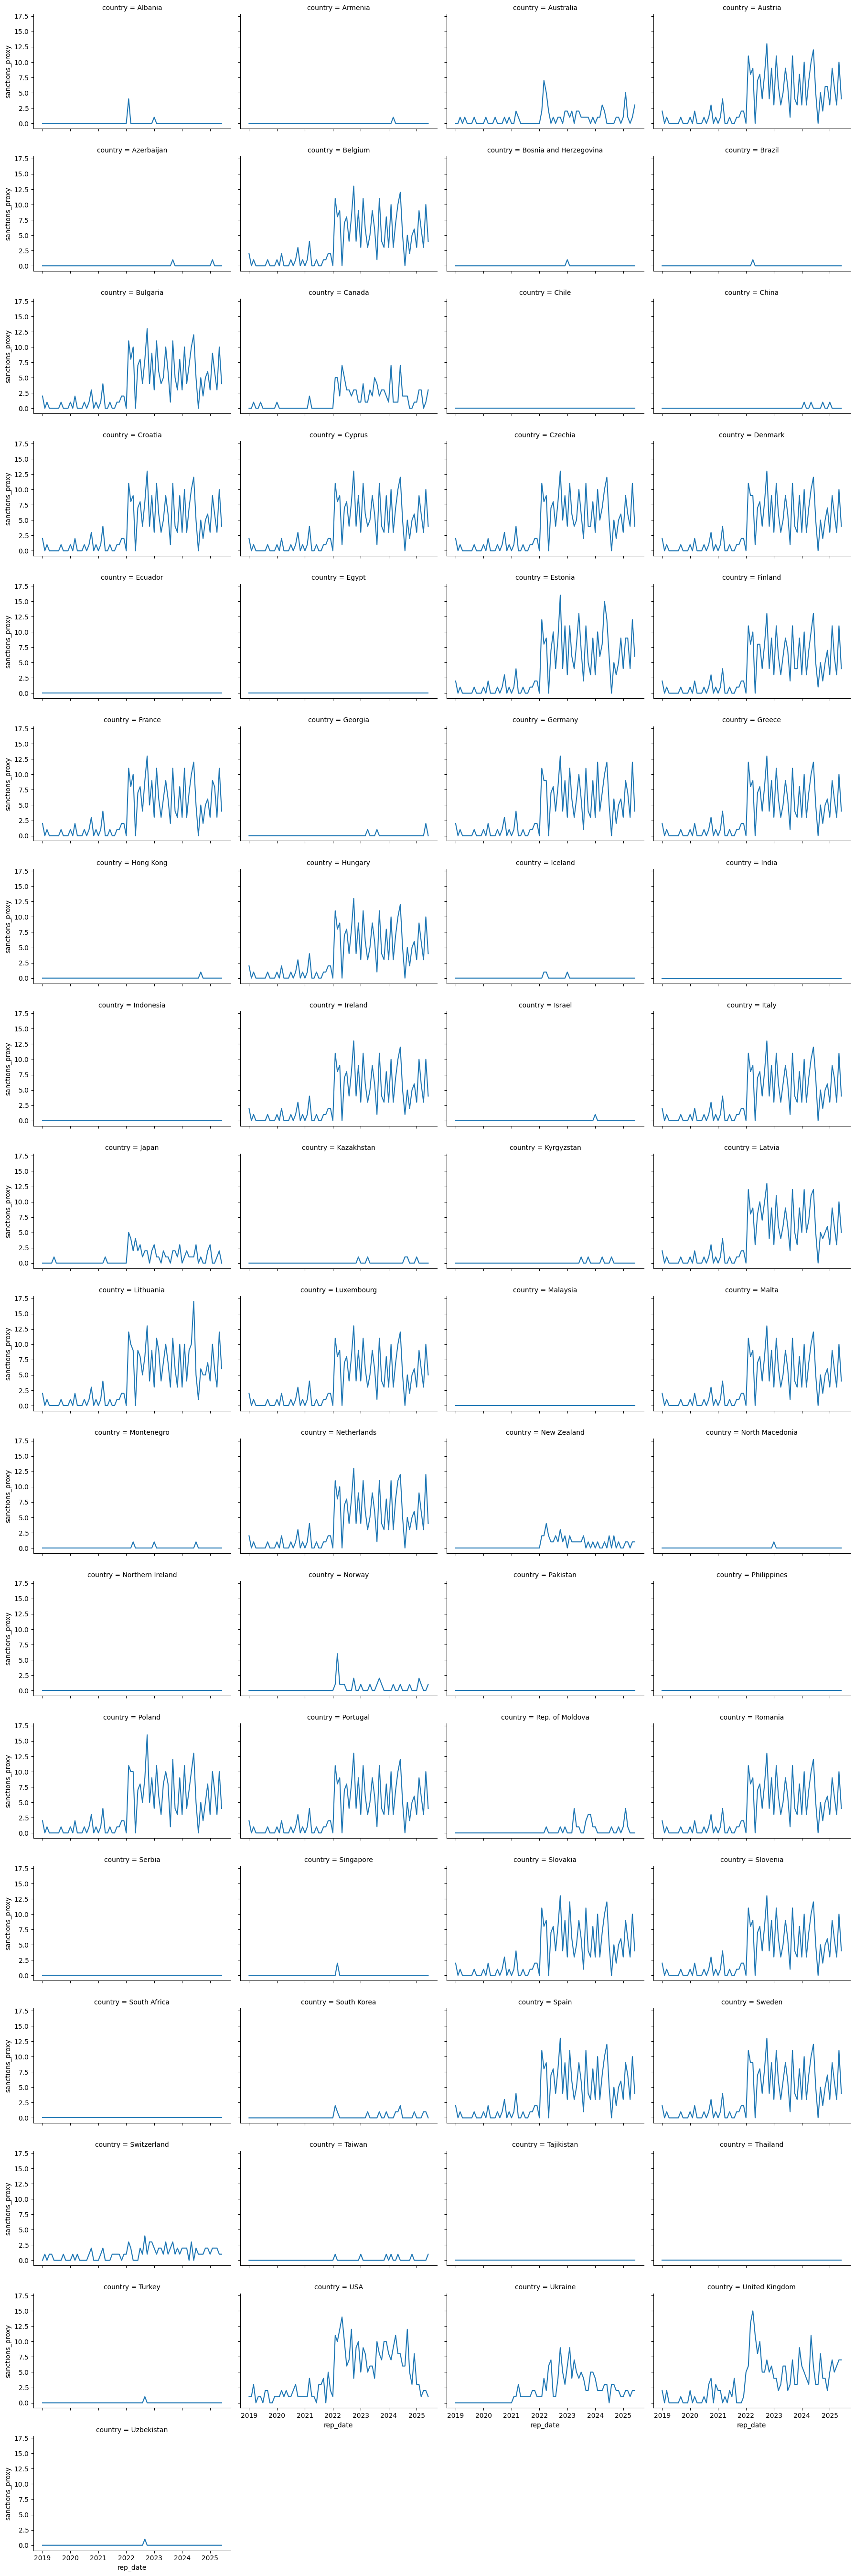

In [16]:
import seaborn as sns
sns.relplot(
    data=sanctions_full,
    x='rep_date',
    y='sanctions_proxy',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

In [17]:
rolling = sanctions_full.sort_values(['country', 'rep_date']).copy()

rolling['sanctions_proxy_smooth'] = (
    rolling.groupby('country')['sanctions_proxy']
      .transform(lambda s: s.rolling(window=3, center=True, min_periods=1).median())
      .round()
      .clip(lower=0)
      .astype(int)
)

rolling

,rep_date,country,sanctions_proxy,sanctions_proxy_smooth
0,2019-01-01,Albania,0,0
1,2019-02-01,Albania,0,0
2,2019-03-01,Albania,0,0
3,2019-04-01,Albania,0,0
4,2019-05-01,Albania,0,0
...,...,...,...,...
5377,2025-02-01,Uzbekistan,0,0
5378,2025-03-01,Uzbekistan,0,0
5379,2025-04-01,Uzbekistan,0,0
5380,2025-05-01,Uzbekistan,0,0


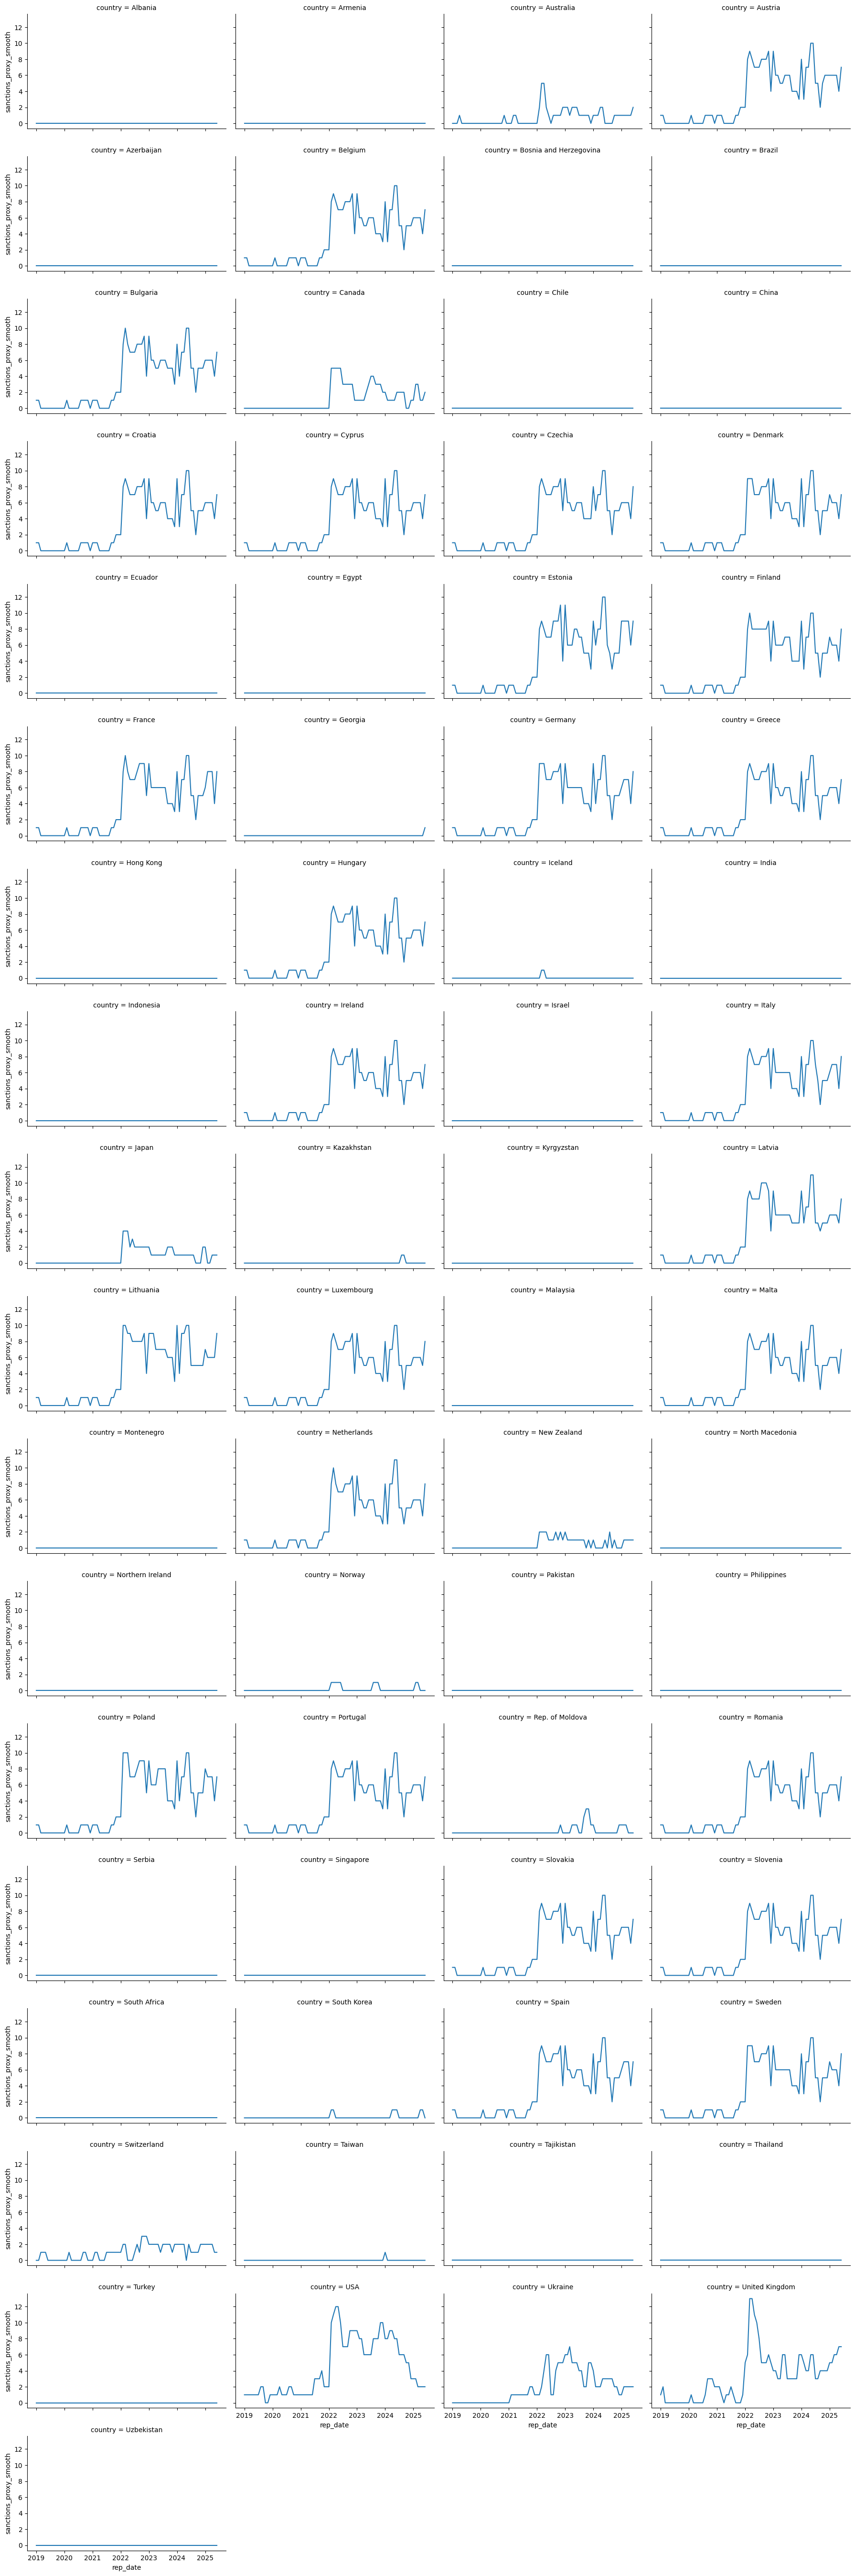

In [18]:
sns.relplot(
    data=rolling,
    x='rep_date',
    y='sanctions_proxy_smooth',
    col='country',
    col_wrap=4,
    kind='line',
    height=3,
    aspect=1.5
)

In [20]:
rolling['country'].nunique()

69

In [21]:
rolling['rep_date'].nunique()

78

In [22]:
rolling.to_excel('data/sanctions_proxy.xlsx', index=False)